<a href="https://colab.research.google.com/github/RubyNixx/BPP_Telecomm_Churn/blob/main/Programming_For_Analysts_Business_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Analysing historic customer churn at BPP Telecom and prediciting future churn.

**Background:**

BPP Telecom, a leading telecommunications provider headquartered in the UK, has been on a progressive journey, expanding its offerings from traditional phone services to a broad spectrum encompassing high-speed internet and cutting-edge streaming services.

**Business Problem:**

Despite the diversification and growth of its services, BPP has been encountering a rising tide of customer churn. This escalating issue has begun to erode its customer base and revenues, posing a clear constraint to the company's future growth trajectory.

**Data used:**

Customer dataset.

**Aim of this notebook:**

Extract key insights from the customer data to construct a predictive model anticipating customer churn.

**Re-submission notes:**

Amendments:
*   Corrected the code that handles the import of PDF and Excel data, all rows now captured, and checks done on data. Included new source column to identify the rows imported from excel / pdf for additional checks.

*   Updated EDA commentary to reflect where values have changed from additional PDF data.

*   Updated training dataset to be called df_train as I think the name of this dataframe caused confusion previously in marking.

*   Updated narrative around model.

---



##Set up enviroment

In [81]:
#Import libraries

#Python libraries are collections of pre-written code and functions that extend the capabilities of the Python programming language. They provide a wide range of tools and modules for various tasks, making it easier to work on specific tasks without reinventing the wheel.

#To use the libraries, we need to import the libraries and give them a alias to use within this project.

#Import pandas for data manipulation and analysis. It offers data structures and operations for manipulating numerical tables and time series.
import pandas as pd

#Import numpy library to add support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
import numpy as np

#Import the matplotlib.pyplot module, which is a popular plotting library in Python.
import matplotlib.pyplot as plt

#Import the Plotly Express library. PX is the easy-to-use, high-level interface to Plotly, which operates on a variety of types of data and produces easy-to-style figures.
import plotly.express as px
#Helpful guide to colours: https://www.w3.org/wiki/CSS/Properties/color/keywords

#Import the Seaborn data visualisation library. Seaborn is built on top of Matplotlib and provides a high-level interface for drawing attractive statistical graphics.
import seaborn as sns

#Import tabula to read data from pdf formatted file.
!pip install tabula-py
import tabula

#Install schkit-learn which is a machine learning library.
!pip install scikit-learn

  #Import train_test_split function from the sklearn.model_selection module. Used for splitting datasets into training and testing sets in machine learning.
from sklearn.model_selection import train_test_split

  #Import the StandardScaler class from the sklearn.preprocessing module. The StandardScaler is a part of the scikit-learn library. It is used for standardising features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler

  #Import OneHotEncoder class from scikit-learn library. The OneHotEncoder converts categorical variables into a format suitable for machine learning algorithms. I've selected this over utilising pandas get_dummies as it handles unknown values better.
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

  #The make_pipeline function is a utility provided by scikit-learn to create a machine learning pipeline.
from sklearn.pipeline import make_pipeline

#Import Classification algorithms from scikit-learn library.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    RandomForestClassifier
)

  #Import three commonly used functions from the scikit-learn library. Used to evaluate classification models: accuracy_score, classification_report, and confusion_matrix.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Set up interactive data tables for notebook
%load_ext google.colab.data_table

The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table


## Data Sourcing & Wrangling

###Source Data

Step 1. Run the below code, which will prompt you to browse and upload files to google colab. Using the browse button, locate the two files below & upload them:

*   bpp_churn_data.pdf
*    bpp_churn_data.xlsx

In [82]:
import os
from google.colab import files

files_to_check = ['bpp_churn_data.xlsx', 'bpp_churn_data.pdf']
files_to_upload = [file for file in files_to_check if not os.path.exists(file)]

if files_to_upload:
    uploaded = files.upload()
else:
    print("All required files already exist. No upload needed.")


#You should now see these files uploaded to 'Files' in the left hand folder on Google Colab.

#Note that the data is sourced from two different files, which are different formats (Excel Workbook and PDF).


#Excel files often contained structured data with defined data types. The unusual part of this is extracting data from a PDF. They are more complex in structure and primarily designed for display rather than data extraction, which can mean the data extracted may be unstructured or requires transformation to match the format of the Excel data. The format doesnt understand tables or columns, which can lead to challenges in accurately extracting tabular data. PDFs can contain hidden or encrypted data, which can prevent successful data extraction, so it's always important to check the data you're importing against the file. The text encoding between a PDF and Excel can also lead to character mismatches or encoding errors during data extraction and merging.


#*I have used the tabula-py library to support extraction of PDF data and the pandas library for excel extraction.*

All required files already exist. No upload needed.


In [83]:
#Store excel file into a DataFrame named df1 using pandas library
df1 = pd.read_excel('bpp_churn_data.xlsx')

#Show top rows of data for quick exploration of what the file contains
df1.head()

#See the dimensions of the DataFrame (number of rows and columns).
df1.shape

#Summarise the DataFrame, including the data types and non-null counts for each column.
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        4900 non-null   object 
 1   gender            4900 non-null   object 
 2   SeniorCitizen     4900 non-null   int64  
 3   Partner           4900 non-null   object 
 4   Dependents        4900 non-null   object 
 5   tenure            4900 non-null   int64  
 6   PhoneService      4900 non-null   object 
 7   MultipleLines     4900 non-null   object 
 8   InternetService   4900 non-null   object 
 9   OnlineSecurity    4900 non-null   object 
 10  OnlineBackup      4900 non-null   object 
 11  DeviceProtection  4900 non-null   object 
 12  TechSupport       4900 non-null   object 
 13  StreamingTV       4900 non-null   object 
 14  StreamingMovies   4900 non-null   object 
 15  Contract          4900 non-null   object 
 16  PaperlessBilling  4900 non-null   object 


In [84]:
# Read existing data from Excel
df1 = pd.read_excel('bpp_churn_data.xlsx')

# Read all pages from the PDF
pdf_path = 'bpp_churn_data.pdf'
pdf_data = tabula.read_pdf(pdf_path, pages='all', multiple_tables=False)

# Combine all tables from the PDF into a single DataFrame
df_pdf = pd.concat(pdf_data, ignore_index=True)

# Print dimensions of Excel and PDF data
print(f"Excel data dimensions: {df1.shape}")
print(f"PDF data dimensions: {df_pdf.shape}")

# Add source column to each DataFrame
df1['Source'] = 'Excel'
df_pdf['Source'] = 'PDF'

# Display the last row of df_pdf
print("\nLast row of PDF DataFrame:")
print(df_pdf.tail(1))

# Append PDF data to existing DataFrame
df_combined = pd.concat([df1, df_pdf], ignore_index=True)

# Remove duplicate rows if any
df_combined = df_combined.drop_duplicates()

# Display the first few rows of the combined DataFrame
print("\nFirst few rows of combined DataFrame:")
print(df_combined.head())

# Check that data frames are expected - Print to screen first & last few rows using head and tail functions.
print("\nFirst few rows:")
print(df_combined.head())
print("\nLast few rows:")
print(df_combined.tail())

# See the dimensions of the DataFrame (number of rows and columns).
print(f"\nCombined DataFrame dimensions: {df_combined.shape}")

# Summarise the DataFrame, including the data types and non-null counts for each column to compare against df1 pre-join.
print("\nCombined DataFrame info:")
df_combined.info()

# Add summary of rows extracted from PDF and Excel
excel_rows = df1.shape[0]
pdf_rows = df_pdf.shape[0]
combined_rows = df_combined.shape[0]

print("\nSummary of extracted rows:")
print(f"Rows extracted from Excel: {excel_rows}")
print(f"Rows extracted from PDF: {pdf_rows}")
print(f"Total rows in combined DataFrame: {combined_rows}")
print(f"Rows removing duplicates: {combined_rows - (excel_rows + pdf_rows)}")


Excel data dimensions: (4900, 21)
PDF data dimensions: (1643, 21)

Last row of PDF DataFrame:
      customerID gender  SeniorCitizen Partner Dependents  tenure  \
1642  3186-AJIEK   Male              0      No         No      66   

     PhoneService MultipleLines InternetService OnlineSecurity  ...  \
1642          Yes            No     Fiber optic            Yes  ...   

     TechSupport StreamingTV StreamingMovies  Contract PaperlessBilling  \
1642         Yes         Yes             Yes  Two year              Yes   

                  PaymentMethod MonthlyCharges TotalCharges  Churn  Source  
1642  Bank transfer (automatic)         105.65       6844.5     No     PDF  

[1 rows x 22 columns]

First few rows of combined DataFrame:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  4374-YMUSQ    Male              0      No         No      34          Yes   
1  4513-CXYIX  Female              1     Yes         No      71          Yes   
2  3957-HHLMR  Fe

###Data Quality and Completeness checks

####**Handling Data Formats**

In [ ]:
#In the following cells I have completed a range of checks on the data to look for data quality, completeness, duplication of records and outliers which may impact analysis.

#Initial EDA on the Entire Dataset: I have conducted an initial EDA to understand the overall structure, distributions, and potential issues in the data. This helps in making informed decisions about data cleaning and preprocessing, but full EDA will follow once the dataset has been cleansed.

#Data Cleaning and Preprocessing: I've applied necessary data cleaning and preprocessing steps to the entire dataset before splitting. This ensures consistency in how the data is treated.

#Summarise the DataFrame, including the data types and non-null counts for each column.
df_combined.info()

####**Handling missing values**

In [ ]:
#Identify missing values in the dataset.
# Count missing values in each column. Could have used isna() as they do the same function, isnull is an alias. There are 2 rows with TotalCharges missing.
missing_values_per_column = df_combined.isnull().sum()
print("Missing values per column:\n", missing_values_per_column)

In [ ]:
# Store the original number of rows
original_rows = df_combined.shape[0]

# Drop rows with NaN values
df_combined = df_combined.dropna()

# Calculate the number of dropped rows
dropped_rows = original_rows - df_combined.shape[0]

# Print the results to confirm the above has worked as intended
print(f"Original number of rows: {original_rows}")
print(f"Number of rows after dropping NaN values: {df_combined.shape[0]}")
print(f"Number of rows dropped: {dropped_rows}")


####**Summarise joined data - initital EDA**

In [85]:
# Loop through each column and find unique values to understand the data more
for column in df_combined.columns:
    unique_values = df_combined[column].unique()
    print(f"Unique values in column '{column}': {unique_values}")


Unique values in column 'customerID': ['4374-YMUSQ' '4513-CXYIX' '3957-HHLMR' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Unique values in column 'gender': ['Male' 'Female']
Unique values in column 'SeniorCitizen': [0 1]
Unique values in column 'Partner': ['No' 'Yes']
Unique values in column 'Dependents': ['No' 'Yes']
Unique values in column 'tenure': [34 71 70 52 69 20 11  2  6  1 61  5 56 30 40 28 27 12 67 29 55 23 72 58
 35 24 68 63 33 60 10 13 39 65 50 15 32 38  3  7 59 47 31  9  4 46 16 51
 66 44  8 57 62 25 49 43 17 45 37 53 22 48 14 26 42  0 41 18 21 36 64 19
 54]
Unique values in column 'PhoneService': ['Yes' 'No']
Unique values in column 'MultipleLines': ['Yes' 'No' 'No phone service']
Unique values in column 'InternetService': ['Fiber optic' 'DSL' 'No']
Unique values in column 'OnlineSecurity': ['Yes' 'No' 'No internet service']
Unique values in column 'OnlineBackup': ['Yes' 'No' 'No internet service']
Unique values in column 'DeviceProtection': ['Yes' 'No' 'No internet serv

####**Final cleansed dataset**

In [86]:
#Final cleansed dataset

# Explore basic statistics of the numerical columns
print(df_combined.describe())

#Final cleansed dataset
df_combined

       SeniorCitizen       tenure  MonthlyCharges
count    6543.000000  6543.000000     6543.000000
mean        0.161700    32.441235       64.669059
std         0.368203    24.570898       30.130797
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.275000
50%         0.000000    29.000000       70.300000
75%         0.000000    56.000000       89.850000
max         1.000000    72.000000      118.750000


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Source
0,4374-YMUSQ,Male,0,No,No,34,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,One year,No,Credit card (automatic),116.25,3899.05,No,Excel
1,4513-CXYIX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,No,No,No,Two year,Yes,Credit card (automatic),80.70,5676,No,Excel
2,3957-HHLMR,Female,0,Yes,Yes,70,Yes,Yes,DSL,Yes,...,No,No,Yes,One year,No,Bank transfer (automatic),65.20,4543.15,No,Excel
3,7803-XOCCZ,Female,0,Yes,Yes,52,Yes,No,Fiber optic,Yes,...,Yes,No,No,Month-to-month,Yes,Bank transfer (automatic),84.05,4326.8,No,Excel
4,5736-YEJAX,Male,0,No,Yes,69,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Credit card (automatic),79.45,5502.55,No,Excel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6538,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,PDF
6539,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,PDF
6540,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,PDF
6541,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,PDF


##**Define Target Variables and Split data into train and test sets**

###*Ethical Considerations and Regulatory Implications*
I've taken a balanced approach to EDA; initital EDA was done to support providing a cleansed dataset that is suitable for analysis. I perform a more detailed EDA on the training dataset to guide feature engineering and model building. The positives of this approach are:

*   **Preventing Data Leakage** Splitting the data before EDA ensures that the insights gained during EDA do not inadvertently influence the model evaluation process. This helps prevent data leakage, where information from the test set could bias the model's performance.
*   **Unbiased Evaluation** By keeping the test set separate, you ensure that the model evaluation is based on data that the model has not seen during the EDA process, providing a more unbiased assessment of the model's performance.

###Define Target Variable

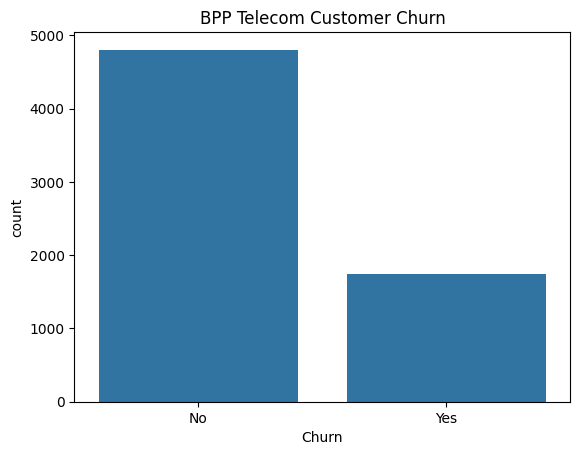

In [87]:
# Show the volume of the target variable ('Churn')
df_combined = df_combined.reset_index(drop=True)
sns.countplot(x='Churn', data=df_combined)
plt.title("BPP Telecom Customer Churn")
plt.show()

In [88]:
# Create a target variable dataset
target_data = df_combined['Churn'].replace({'Yes':1, 'No':0})

#View target_data
target_data

<ipython-input-88-61a9d1b8c4cb>:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,Churn
0,0
1,0
2,0
3,0
4,0
...,...
6538,0
6539,0
6540,0
6541,1


###Define features data

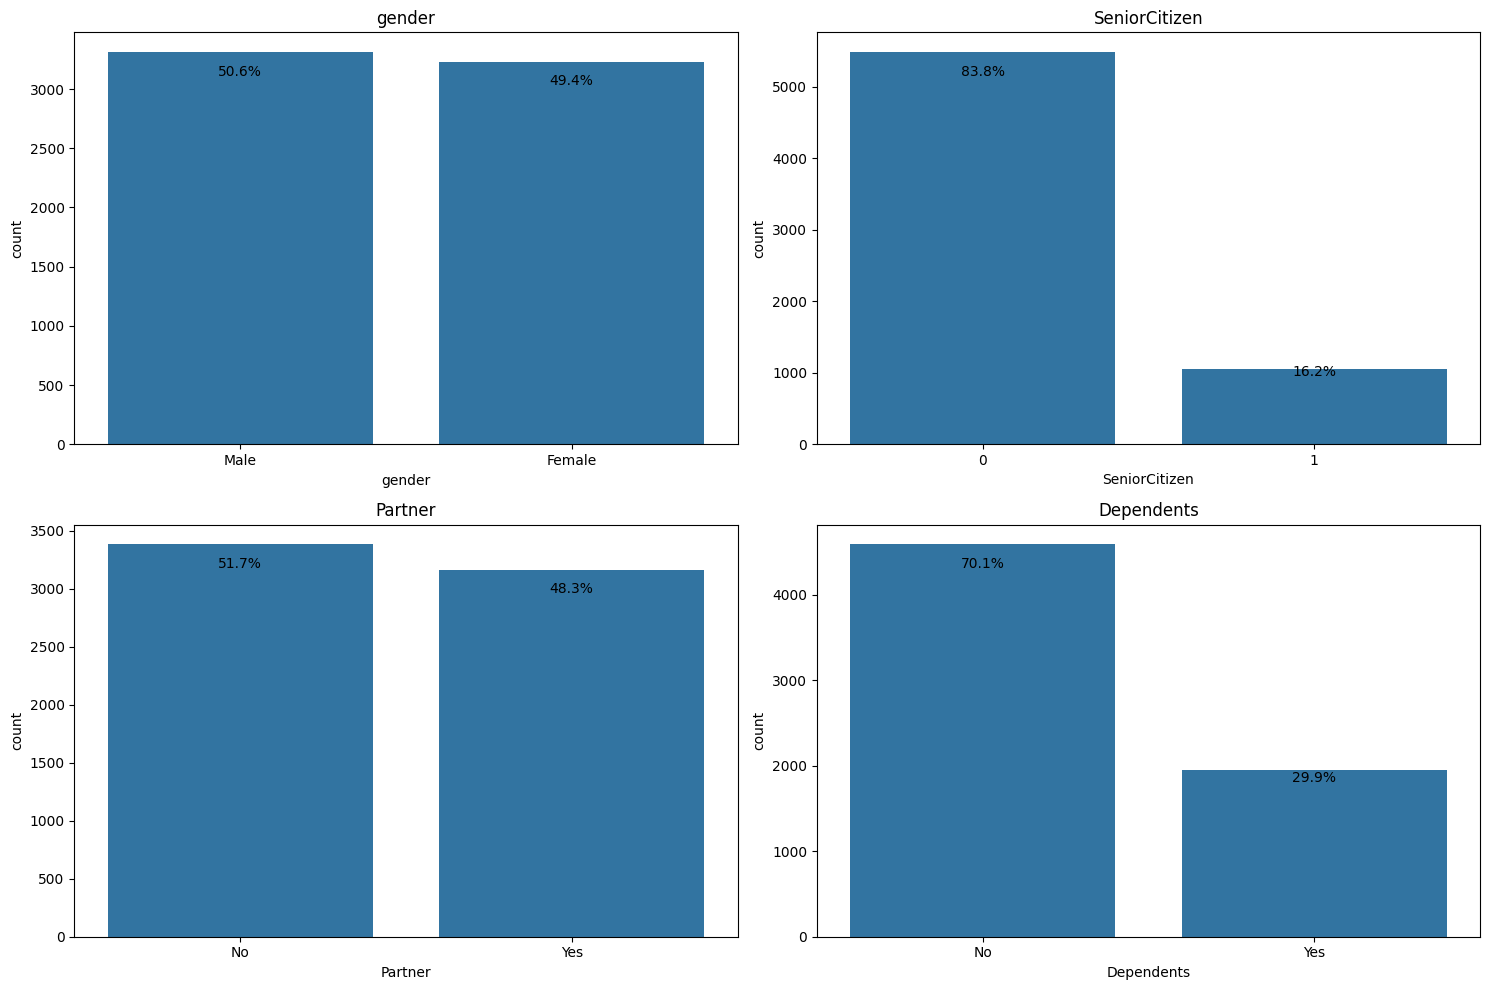

In [89]:
df_combined

# Assuming 'datc' is your DataFrame
# If not, replace 'datc' with your actual DataFrame name

def create_bar_plot(data, x_column, ax):
    # Create the bar plot
    sns.countplot(x=x_column, data=data, ax=ax)

    #Calculate percentages for each variable
    total = len(data)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height() - (p.get_height() * 0.05)  #Adjust this value to position the text
        ax.annotate(percentage, (x, y), ha='center', va='center')

    ax.set_title(x_column)

# Create a grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 10)) #Adjust subplots to how many plots you want displayed in the grid down & across. Use figsize to change the size of each of the plots.
axs = axs.flatten()

# Create each plot
create_bar_plot(df_combined, 'gender', axs[0])
create_bar_plot(df_combined, 'SeniorCitizen', axs[1])
create_bar_plot(df_combined, 'Partner', axs[2])
create_bar_plot(df_combined, 'Dependents', axs[3])

# Adjust layout and show plot
plt.tight_layout()
plt.show()



In [90]:
# Create features dataset and drop the columns not needed

features_data = df_combined.drop(['customerID'], axis=1)

features_data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Source
0,Male,0,No,No,34,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Yes,One year,No,Credit card (automatic),116.25,3899.05,No,Excel
1,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,No,...,No,No,No,Two year,Yes,Credit card (automatic),80.70,5676,No,Excel
2,Female,0,Yes,Yes,70,Yes,Yes,DSL,Yes,No,...,No,No,Yes,One year,No,Bank transfer (automatic),65.20,4543.15,No,Excel
3,Female,0,Yes,Yes,52,Yes,No,Fiber optic,Yes,No,...,Yes,No,No,Month-to-month,Yes,Bank transfer (automatic),84.05,4326.8,No,Excel
4,Male,0,No,Yes,69,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,No,Two year,Yes,Credit card (automatic),79.45,5502.55,No,Excel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6538,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,PDF
6539,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,PDF
6540,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,PDF
6541,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,PDF


###Convert Categorical data into counts


In [91]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Initialise the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# List of features to encode
features_to_encode = ['gender', 'PhoneService', 'MultipleLines']

# Initialize an empty DataFrame to store all encoded features
df_encoded_all = pd.DataFrame()

# Encode each feature and add to df_encoded_all
for feature in features_to_encode:
    # Fit and transform the data
    encoded_data = encoder.fit_transform(features_data[[feature]])

    # Create a new dataframe with encoded data
    df_encoded = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([feature]))

    # Add to df_encoded_all
    df_encoded_all = pd.concat([df_encoded_all, df_encoded], axis=1)

# Reset index of both dataframes
df_encoded_all = df_encoded_all.reset_index(drop=True)
features_data = features_data.reset_index(drop=True)

# Concatenate the encoded columns with the original dataframe
features_data_encoded = pd.concat([features_data, df_encoded_all], axis=1)

print(features_data_encoded)


      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0       Male              0      No         No      34          Yes   
1     Female              1     Yes         No      71          Yes   
2     Female              0     Yes        Yes      70          Yes   
3     Female              0     Yes        Yes      52          Yes   
4       Male              0      No        Yes      69          Yes   
...      ...            ...     ...        ...     ...          ...   
6538    Male              0     Yes        Yes      24          Yes   
6539  Female              0     Yes        Yes      72          Yes   
6540  Female              0     Yes        Yes      11           No   
6541    Male              1     Yes         No       4          Yes   
6542    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0                  Yes     Fiber optic            Yes          Yes  ... 

###Create new columns based on condition


In [92]:
#Use the values of multiple columns to create new columns.

#1. Column called 'multi_occupancy' to show where there are multiple people living at one address based on if the customer is listed as having a partner or children.
#2. Column called 'additional_services' to use all the columns that suggest the customer has bought or interacted with additional services.


#Create new column for multi_occupancy
def set_multi_occupancy(row):
    if row['Partner'] == 'Yes' or row['Dependents'] == 'Yes':
        return 1
    else:
        return 0

features_data_encoded['multi_occupancy'] = features_data_encoded.apply(set_multi_occupancy, axis=1)

#Create new column for additional_services
def set_add_service(row):
    if row['OnlineSecurity'] == 'Yes' or row['OnlineBackup'] == 'Yes' or row['DeviceProtection'] == 'Yes' or row['TechSupport'] == 'Yes' or row['StreamingTV'] == 'Yes' or row['StreamingMovies'] == 'Yes':
        return 1
    else:
        return 0

features_data_encoded['additional_services'] = features_data_encoded.apply(set_add_service, axis=1)

#Create new column for automatic_payment
def set_auto_payment(row):
    automatic_methods = ['Credit card (automatic)', 'Bank transfer (automatic)']
    if row['PaymentMethod'] in automatic_methods:
        return 1
    else:
        return 0

features_data_encoded['auto_payment'] = features_data_encoded.apply(set_auto_payment, axis=1)

#Create new column for Internet_High_Speed
def set_internet_high_speed(row):
    if row['InternetService'] == 'Fiber optic':
        return 1
    else:
        return 0

features_data_encoded['internet_high_speed'] = features_data_encoded.apply(set_internet_high_speed, axis=1)

#Create new column for Internet_Service
def set_internet_service(row):
    if row['InternetService'] != 'No':
        return 1
    else:
        return 0

features_data_encoded['internet_service'] = features_data_encoded.apply(set_internet_service, axis=1)

#Create new column for Contract_Monthly
def set_contract_monthly(row):
    if row['Contract'] == 'Month-to-month':
        return 1
    else:
        return 0

features_data_encoded['contract_monthly'] = features_data_encoded.apply(set_contract_monthly, axis=1)

features_data_encoded

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,multi_occupancy,additional_services,auto_payment,internet_high_speed,internet_service,contract_monthly
0,Male,0,No,No,34,Yes,Yes,Fiber optic,Yes,Yes,...,1.0,0.0,0.0,1.0,0,1,1,1,1,0
1,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,No,...,1.0,0.0,0.0,1.0,1,1,1,1,1,0
2,Female,0,Yes,Yes,70,Yes,Yes,DSL,Yes,No,...,1.0,0.0,0.0,1.0,1,1,1,0,1,0
3,Female,0,Yes,Yes,52,Yes,No,Fiber optic,Yes,No,...,1.0,1.0,0.0,0.0,1,1,1,1,1,1
4,Male,0,No,Yes,69,Yes,Yes,DSL,Yes,Yes,...,1.0,0.0,0.0,1.0,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6538,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,1.0,0.0,0.0,1.0,1,1,0,0,1,0
6539,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,1.0,0.0,0.0,1.0,1,1,1,1,1,0
6540,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,0.0,0.0,1.0,0.0,1,1,0,0,1,1
6541,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,1.0,0.0,0.0,1.0,1,0,0,1,1,1


###Drop columns not needed & create smaller dataset


In [93]:
#Drop all the columns where we've converted them into numerical columns, the columns won't be used in analysis e.g. paperless billing, and where we only need the one hot encoded column that captures 'Yes' e.g. Multiple Lines.

# Drop columns no longer needed due to new fields created

features_data_encoded = features_data_encoded.drop(['Partner','Dependents','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','TotalCharges','PaymentMethod','MultipleLines','PhoneService','PaperlessBilling','MultipleLines_No','MultipleLines_No phone service','InternetService','Contract','gender_Male','Source'], axis=1)

# Rename MultipleLines_Yes to MultipleLines
features_data_encoded = features_data_encoded.rename(columns={'MultipleLines_Yes': 'MultipleLines'})

features_data_encoded

,gender,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Female,PhoneService_No,PhoneService_Yes,MultipleLines,multi_occupancy,additional_services,auto_payment,internet_high_speed,internet_service,contract_monthly
0,Male,0,34,116.25,No,0.0,0.0,1.0,1.0,0,1,1,1,1,0
1,Female,1,71,80.70,No,1.0,0.0,1.0,1.0,1,1,1,1,1,0
2,Female,0,70,65.20,No,1.0,0.0,1.0,1.0,1,1,1,0,1,0
3,Female,0,52,84.05,No,1.0,0.0,1.0,0.0,1,1,1,1,1,1
4,Male,0,69,79.45,No,0.0,0.0,1.0,1.0,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6538,Male,0,24,84.80,No,0.0,0.0,1.0,1.0,1,1,0,0,1,0
6539,Female,0,72,103.20,No,1.0,0.0,1.0,1.0,1,1,1,1,1,0
6540,Female,0,11,29.60,No,1.0,1.0,0.0,0.0,1,1,0,0,1,1
6541,Male,1,4,74.40,Yes,0.0,0.0,1.0,1.0,1,0,0,1,1,1


In [94]:
# Re-alias dataframes into features (X) and target variable (y)
X = features_data_encoded
y = target_data

# Split the data into train & test data. Common split ratios are 80/20 or 70/30 (train/test). In this step 20% of the data has been selected as test data using test_size=0.2. The 'random_state' parameter ensures reproducibility, you can use any integer here. Stratify=y is used as an additional parameter in train_test_split to ensure that the proportion of samples for each class is roughly the same in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [95]:
# Check the shapes of the test & train datasets:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)



Training set shape: (5234, 15)
Test set shape: (1309, 15)


In [96]:
#Create a separate copy of your data for exploration and analysis. X_train + y+train = df_train

df_train = X_train.join(y_train.reset_index(drop=True), rsuffix='_target')


##**Exploratory Data Analysis**

###Tenure and Monthly Charges

Key insights:


*   Average tenure of 33 months
*   Highest 25%: 56 months and 72 months
*   Minimum tenure: 0 months
*   Lowest 25%: under 9 months
*   Average charges: £64.89 per month
*   Highest 25%: between £89.95 and £118.75
*   Minimum charge: £18.25
*   Lowest 25% of customers paying below £35.73



In [97]:
#Define which columns to focus on
values_data = ["tenure","MonthlyCharges"]

#Provide some basic stats to support the descriptive summary above.
df_train[values_data].describe()

,tenure,MonthlyCharges
count,5234.000000,5234.000000
mean,32.641001,64.847726
std,24.701460,30.105233
min,0.000000,18.250000
25%,9.000000,35.712500
50%,29.000000,70.300000
75%,56.000000,89.900000
max,72.000000,118.750000


In [98]:
#Set up a boxplot
def Outlier_boxplot(df, col):
    """ Display boxplot for given column """
    sns.boxplot(x=df[col])
    plt.show()

No outliers found.

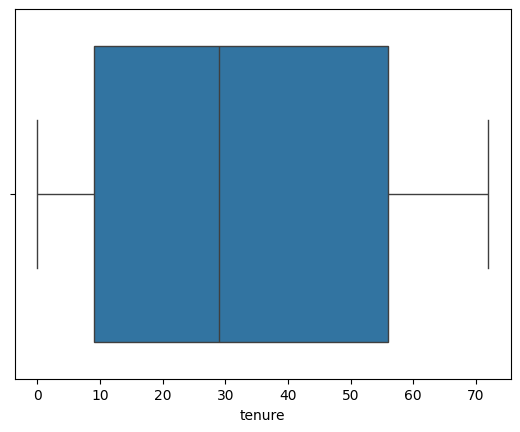

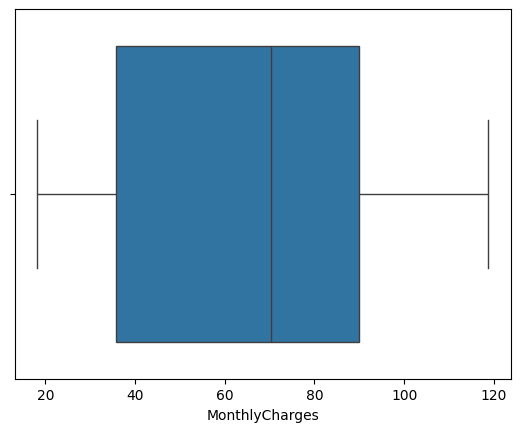

In [99]:
 #Create boxplots using the tenure & monthly charge data
for i in values_data:
    Outlier_boxplot(df_train,i)

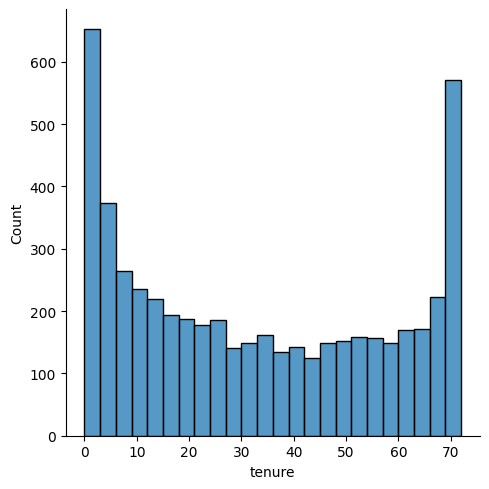

In [100]:
sns.displot(df_train, x="tenure", binwidth=3);

Large volume of customers that have low rates. Excluding this bar, the Monthly Charges seems to be normally distributed, roughly distributed around £80 per month.


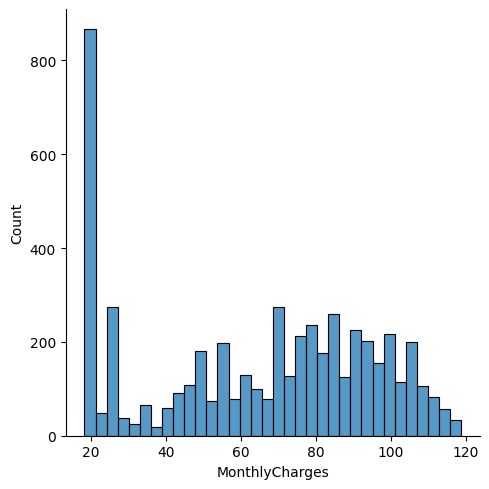

In [101]:
sns.displot(df_train, x="MonthlyCharges", binwidth=3);

###Age Profile


In [102]:
# Count the number of occurrences of each value in the 'SeniorCitizen' column
value_counts = df_train['SeniorCitizen'].value_counts()

print("Counts of each value in the 'SeniorCitizen' column:")
print(value_counts)

Counts of each value in the 'SeniorCitizen' column:
SeniorCitizen
0    4399
1     835
Name: count, dtype: int64


24.7% of customers that leave are senior citizens.

In [103]:
# Rename SeniorCitizen values
df_train['SeniorCitizen'] = df_train['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# Calculate percentages for each combination of Churn and SeniorCitizen
grouped = df_train.groupby(['Churn', 'SeniorCitizen']).size().reset_index(name='Count')
total_counts = df_train.groupby('Churn').size().reset_index(name='Total')
percentages = pd.merge(grouped, total_counts, on='Churn')
percentages['Percentage'] = (percentages['Count'] / percentages['Total']) * 100

#Colour mapping
color = {'No': 'grey', 'Yes': 'red'}

fig = px.histogram(df_train,
                   x="Churn",
                   color="SeniorCitizen",
                   barmode="stack",
                   color_discrete_map=color)

fig.update_layout(
    width=700,
    height=500,
    bargap=0.1,
    title='Churn distribution by Senior Citizen'
)

# Add percentage annotations
for churn in df_train['Churn'].unique():
    y_offset = 0
    for senior_citizen in ['No', 'Yes']:  # Process 'Yes' (red) first, then 'No' (grey)
        row = percentages[(percentages['Churn'] == churn) & (percentages['SeniorCitizen'] == senior_citizen)]
        if not row.empty:
            count = row['Count'].values[0]
            percentage = row['Percentage'].values[0]
            y_position = y_offset + (count / 2)
            fig.add_annotation(
                x=churn,
                y=y_position,
                text=f"{percentage:.1f}%",
                showarrow=False,
                font=dict(color="white" if senior_citizen == 'Yes' else "black")
            )
            y_offset += count  # Update offset for the next segment

fig.show()

###Churn by Gender

In [104]:
# Count the number of occurrences of each value in the 'Gender' column
value_counts = df_train['gender'].value_counts()

print("Counts of each value in the 'Gender' column:")
print(value_counts)

Counts of each value in the 'Gender' column:
gender
Male      2645
Female    2589
Name: count, dtype: int64


In [105]:
# Rename gender_Female values (1 is Female and 0 is Male)
df_train['gender_Female'] = df_train['gender_Female'].map({1: 'Female', 0: 'Male'})

# Calculate percentages for each combination of Churn and gender_Female
grouped = df_train.groupby(['Churn', 'gender_Female']).size().reset_index(name='Count')
total_counts = df_train.groupby('Churn').size().reset_index(name='Total')
percentages = pd.merge(grouped, total_counts, on='Churn')
percentages['Percentage'] = (percentages['Count'] / percentages['Total']) * 100

# Update color mapping
color = {'Male': 'SteelBlue', 'Female': 'MistyRose'}

fig = px.histogram(df_train,
                   x="Churn",
                   color="gender_Female",
                   barmode="stack",
                   color_discrete_map=color)

fig.update_layout(
    width=700,
    height=500,
    bargap=0.1,
    title='Churn distribution by Gender',
    legend_title_text='Gender'
)

# Add percentage annotations
for churn in df_train['Churn'].unique():
    y_offset = 0
    for gender in ['Female', 'Male']:  # Process 'Female' first, then 'Male'
        row = percentages[(percentages['Churn'] == churn) & (percentages['gender_Female'] == gender)]
        if not row.empty:
            count = row['Count'].values[0]
            percentage = row['Percentage'].values[0]
            y_position = y_offset + (count / 2)
            fig.add_annotation(
                x=churn,
                y=y_position,
                text=f"{percentage:.1f}%",
                showarrow=False,
                font=dict(color="black" if gender == 'Female' else "white")
            )
            y_offset += count  # Update offset for the next segment

fig.show()


###Churn by Internet Service



In [106]:
# Count the number of occurrences of each value in the 'internetservice' column
value_counts1 = df_train['internet_service'].value_counts()

print("Counts of each value in the 'internetservice' column:")
print(value_counts1)

# Count the number of occurrences of each value in the 'internet_high_speed' column
value_counts2 = df_train['internet_high_speed'].value_counts()

print("Counts of each value in the 'internet_high_speed' column:")
print(value_counts2)

Counts of each value in the 'internetservice' column:
internet_service
1    4100
0    1134
Name: count, dtype: int64
Counts of each value in the 'internet_high_speed' column:
internet_high_speed
0    2930
1    2304
Name: count, dtype: int64


94 in 100 customers have a internet service.

In [107]:
# Calculate percentages for each combination of Churn and internet_service
grouped = df_train.groupby(['Churn', 'internet_service']).size().reset_index(name='Count')
total_counts = df_train.groupby('Churn').size().reset_index(name='Total')
percentages = pd.merge(grouped, total_counts, on='Churn')
percentages['Percentage'] = (percentages['Count'] / percentages['Total']) * 100

# Get unique internet_service values
internet_services = df_train['internet_service'].unique()

# Define colour mapping for internet_service
color_map = {
    internet_services[0]: 'darkseagreen',  # First category
    internet_services[1]: 'cornsilk'     # Second category
}

fig = px.histogram(df_train,
                   x="Churn",
                   color="internet_service",
                   barmode="stack",
                   color_discrete_map=color_map)

fig.update_layout(
    width=700,
    height=500,
    bargap=0.1,
    title='Churn distribution by Internet Service',
    legend_title_text='Internet Service'
)

# Add percentage annotations
for churn in df_train['Churn'].unique():
    y_offset = 0
    for service in internet_services:
        row = percentages[(percentages['Churn'] == churn) & (percentages['internet_service'] == service)]
        if not row.empty:
            count = row['Count'].values[0]
            percentage = row['Percentage'].values[0]
            y_position = y_offset + (count / 2)
            fig.add_annotation(
                x=churn,
                y=y_position,
                text=f"{percentage:.1f}%",
                showarrow=False,
                font=dict(color="black")
            )
            y_offset += count  # Update offset for the next segment

fig.show()


In [108]:
# Calculate percentages for each combination of Churn and internet_high_speed
grouped = df_train.groupby(['Churn', 'internet_high_speed']).size().reset_index(name='Count')
total_counts = df_train.groupby('Churn').size().reset_index(name='Total')
percentages = pd.merge(grouped, total_counts, on='Churn')
percentages['Percentage'] = (percentages['Count'] / percentages['Total']) * 100

# Get unique internet_high_speed values
internet_high_speeds = df_train['internet_high_speed'].unique()

# Define colour mapping for internet_high_speed
color_map = {
    internet_high_speeds[0]: 'darkseagreen',  # First category
    internet_high_speeds[1]: 'cornsilk'     # Second category
}

fig = px.histogram(df_train,
                   x="Churn",
                   color="internet_high_speed",
                   barmode="stack",
                   color_discrete_map=color_map)

fig.update_layout(
    width=700,
    height=500,
    bargap=0.1,
    title='Churn distribution by High Speed Internet Service',
    legend_title_text='High Speed Internet Service'
)

# Add percentage annotations
for churn in df_train['Churn'].unique():
    y_offset = 0
    for service in internet_high_speeds:
        row = percentages[(percentages['Churn'] == churn) & (percentages['internet_high_speed'] == service)]
        if not row.empty:
            count = row['Count'].values[0]
            percentage = row['Percentage'].values[0]
            y_position = y_offset + (count / 2)
            fig.add_annotation(
                x=churn,
                y=y_position,
                text=f"{percentage:.1f}%",
                showarrow=False,
                font=dict(color="black")
            )
            y_offset += count  # Update offset for the next segment

fig.show()


###Churn by Additional Services


In [109]:
# Calculate percentages for each combination of Churn and additional_services
grouped = df_train.groupby(['Churn', 'additional_services']).size().reset_index(name='Count')
total_counts = df_train.groupby('Churn').size().reset_index(name='Total')
percentages = pd.merge(grouped, total_counts, on='Churn')
percentages['Percentage'] = (percentages['Count'] / percentages['Total']) * 100

# Get unique additional_services values
additional_servicess = df_train['additional_services'].unique()

# Define colour mapping for additional_services
color_map = {
    additional_servicess[0]: 'darkseagreen',  # First category
    additional_servicess[1]: 'cornsilk'     # Second category
}

fig = px.histogram(df_train,
                   x="Churn",
                   color="additional_services",
                   barmode="stack",
                   color_discrete_map=color_map)

fig.update_layout(
    width=700,
    height=500,
    bargap=0.1,
    title='Churn distribution by Additional Services',
    legend_title_text='Additional Services'
)

# Add percentage annotations
for churn in df_train['Churn'].unique():
    y_offset = 0
    for service in additional_servicess:
        row = percentages[(percentages['Churn'] == churn) & (percentages['additional_services'] == service)]
        if not row.empty:
            count = row['Count'].values[0]
            percentage = row['Percentage'].values[0]
            y_position = y_offset + (count / 2)
            fig.add_annotation(
                x=churn,
                y=y_position,
                text=f"{percentage:.1f}%",
                showarrow=False,
                font=dict(color="black")
            )
            y_offset += count  # Update offset for the next segment

fig.show()


###Churn by Contract Type

88% of customers that churn are on a month-to-month contract.

In [110]:
# Calculate percentages for each combination of Churn and contract_monthly
grouped = df_train.groupby(['Churn', 'contract_monthly']).size().reset_index(name='Count')
total_counts = df_train.groupby('Churn').size().reset_index(name='Total')
percentages = pd.merge(grouped, total_counts, on='Churn')
percentages['Percentage'] = (percentages['Count'] / percentages['Total']) * 100

# Get unique contract_monthly values
contract_monthlys = df_train['contract_monthly'].unique()

# Define colour mapping for contract_monthly
color_map = {
    contract_monthlys[0]: 'darkseagreen',  # First category
    contract_monthlys[1]: 'cornsilk'     # Second category
}

fig = px.histogram(df_train,
                   x="Churn",
                   color="contract_monthly",
                   barmode="stack",
                   color_discrete_map=color_map)

fig.update_layout(
    width=700,
    height=500,
    bargap=0.1,
    title='Churn distribution by Monthly Contract',
    legend_title_text='Monthly Contract'
)

# Add percentage annotations
for churn in df_train['Churn'].unique():
    y_offset = 0
    for service in contract_monthlys:
        row = percentages[(percentages['Churn'] == churn) & (percentages['contract_monthly'] == service)]
        if not row.empty:
            count = row['Count'].values[0]
            percentage = row['Percentage'].values[0]
            y_position = y_offset + (count / 2)
            fig.add_annotation(
                x=churn,
                y=y_position,
                text=f"{percentage:.1f}%",
                showarrow=False,
                font=dict(color="black")
            )
            y_offset += count  # Update offset for the next segment

fig.show()


### Churn by Payment Method

73.4% of customers that churn are not using a automated payment method.

In [111]:
# Calculate percentages for each combination of Churn and auto_payment
grouped = df_train.groupby(['Churn', 'auto_payment']).size().reset_index(name='Count')
total_counts = df_train.groupby('Churn').size().reset_index(name='Total')
percentages = pd.merge(grouped, total_counts, on='Churn')
percentages['Percentage'] = (percentages['Count'] / percentages['Total']) * 100

# Get unique auto_payment values
auto_payments = df_train['auto_payment'].unique()

# Define colour mapping for auto_payment
color_map = {
    auto_payments[1]: 'darkseagreen',  # First category
    auto_payments[0]: 'cornsilk'     # Second category
}

fig = px.histogram(df_train,
                   x="Churn",
                   color="auto_payment",
                   barmode="stack",
                   color_discrete_map=color_map)

fig.update_layout(
    width=700,
    height=500,
    bargap=0.1,
    title='Churn distribution by Automated payment',
    legend_title_text='Automated payment'
)

# Add percentage annotations
for churn in df_train['Churn'].unique():
    y_offset = 0
    for service in auto_payments:
        row = percentages[(percentages['Churn'] == churn) & (percentages['auto_payment'] == service)]
        if not row.empty:
            count = row['Count'].values[0]
            percentage = row['Percentage'].values[0]
            y_position = y_offset + (count / 2)  # Center the label in the bar segment
            fig.add_annotation(
                x=churn,
                y=y_position,
                text=f"{percentage:.1f}%",
                showarrow=False,
                font=dict(color="black")  # Changed to black for better visibility on all colors
            )
            y_offset += count  # Update offset for the next segment

fig.show()


###Drop columns to train & test model

In [112]:
# Drop columns no longer for EDA as we're not going to use these features to train and test our model.

X_test = X_test.drop(['gender','Churn','PhoneService_No','gender_Female'], axis=1)
X_train = X_train.drop(['gender','Churn','PhoneService_No','gender_Female'], axis=1)
X = X.drop(['gender','Churn','PhoneService_No','gender_Female'], axis=1)



In [113]:
#Write a function to check that all datasets have the same columns

def compare_column_names(*dataframes):
    names = [set(df.columns) for df in dataframes]
    if len(set(map(frozenset, names))) == 1:
        print("All datasets have the same column names.")
        print("Columns:", sorted(list(names[0])))
    else:
        print("Datasets have different column names.")
        for i, columns in enumerate(names):
            print(f"Dataset {i + 1} columns:", sorted(list(columns)))

        # Find and print the differences
        all_columns = set.union(*names)
        for i, columns in enumerate(names):
            missing = all_columns - columns
            if missing:
                print(f"Columns missing in Dataset {i + 1}:", sorted(list(missing)))

# Call the function with your datasets
compare_column_names(X_test, X_train, X)

All datasets have the same column names.
Columns: ['MonthlyCharges', 'MultipleLines', 'PhoneService_Yes', 'SeniorCitizen', 'additional_services', 'auto_payment', 'contract_monthly', 'internet_high_speed', 'internet_service', 'multi_occupancy', 'tenure']


## Build a model to predict Churn

We have tried 7 different machine learning (ML) algorithms using default parameters to then select the classification model that can predict churn.

Different algorithms have varying strengths and weaknesses. By implementing multiple models, we can compare their performance to find the best one for our dataset and business problem. Having no experience in ML models to use for prediction, I researched prediction models and utilised the most common. Within an article on wine analysis, I found that the logistic model was easy to interpret and had high accuracy however the ROC curve indicated low performance. Cartaya, C. (2021). This helped my understanding and considering multiple methods for model selection.

In [114]:
# Define the models
models = {
    'Extra Trees': make_pipeline(StandardScaler(), ExtraTreesClassifier(random_state=42)),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(random_state=42)),
    'K-Nearest Neighbors': make_pipeline(StandardScaler(), KNeighborsClassifier()),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Dictionary to store results
results = {}

# Function to evaluate model
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': cm
    }

# Evaluate all models
for name, model in models.items():
    evaluate_model(model, name)

# Print results
for name, result in results.items():
    print(f"\n{name}:")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print("\nClassification Report:")
    for label, metrics in result['report'].items():
        if isinstance(metrics, dict):
            print(f"{label:>20s}: Precision: {metrics['precision']:.4f}, "
                  f"Recall: {metrics['recall']:.4f}, F1-score: {metrics['f1-score']:.4f}")

    print("\nConfusion Matrix:")
    print(result['confusion_matrix'])


Extra Trees:
Accuracy: 0.7426

Classification Report:
                   0: Precision: 0.8126, Recall: 0.8439, F1-score: 0.8280
                   1: Precision: 0.5177, Recall: 0.4626, F1-score: 0.4886
           macro avg: Precision: 0.6652, Recall: 0.6533, F1-score: 0.6583
        weighted avg: Precision: 0.7342, Recall: 0.7426, F1-score: 0.7378

Confusion Matrix:
[[811 150]
 [187 161]]

Gradient Boosting:
Accuracy: 0.7998

Classification Report:
                   0: Precision: 0.8344, Recall: 0.9074, F1-score: 0.8694
                   1: Precision: 0.6629, Recall: 0.5029, F1-score: 0.5719
           macro avg: Precision: 0.7487, Recall: 0.7051, F1-score: 0.7206
        weighted avg: Precision: 0.7888, Recall: 0.7998, F1-score: 0.7903

Confusion Matrix:
[[872  89]
 [173 175]]

Logistic Regression:
Accuracy: 0.7937

Classification Report:
                   0: Precision: 0.8411, Recall: 0.8866, F1-score: 0.8632
                   1: Precision: 0.6318, Recall: 0.5374, F1-score: 0.58

###Confusion Matrices

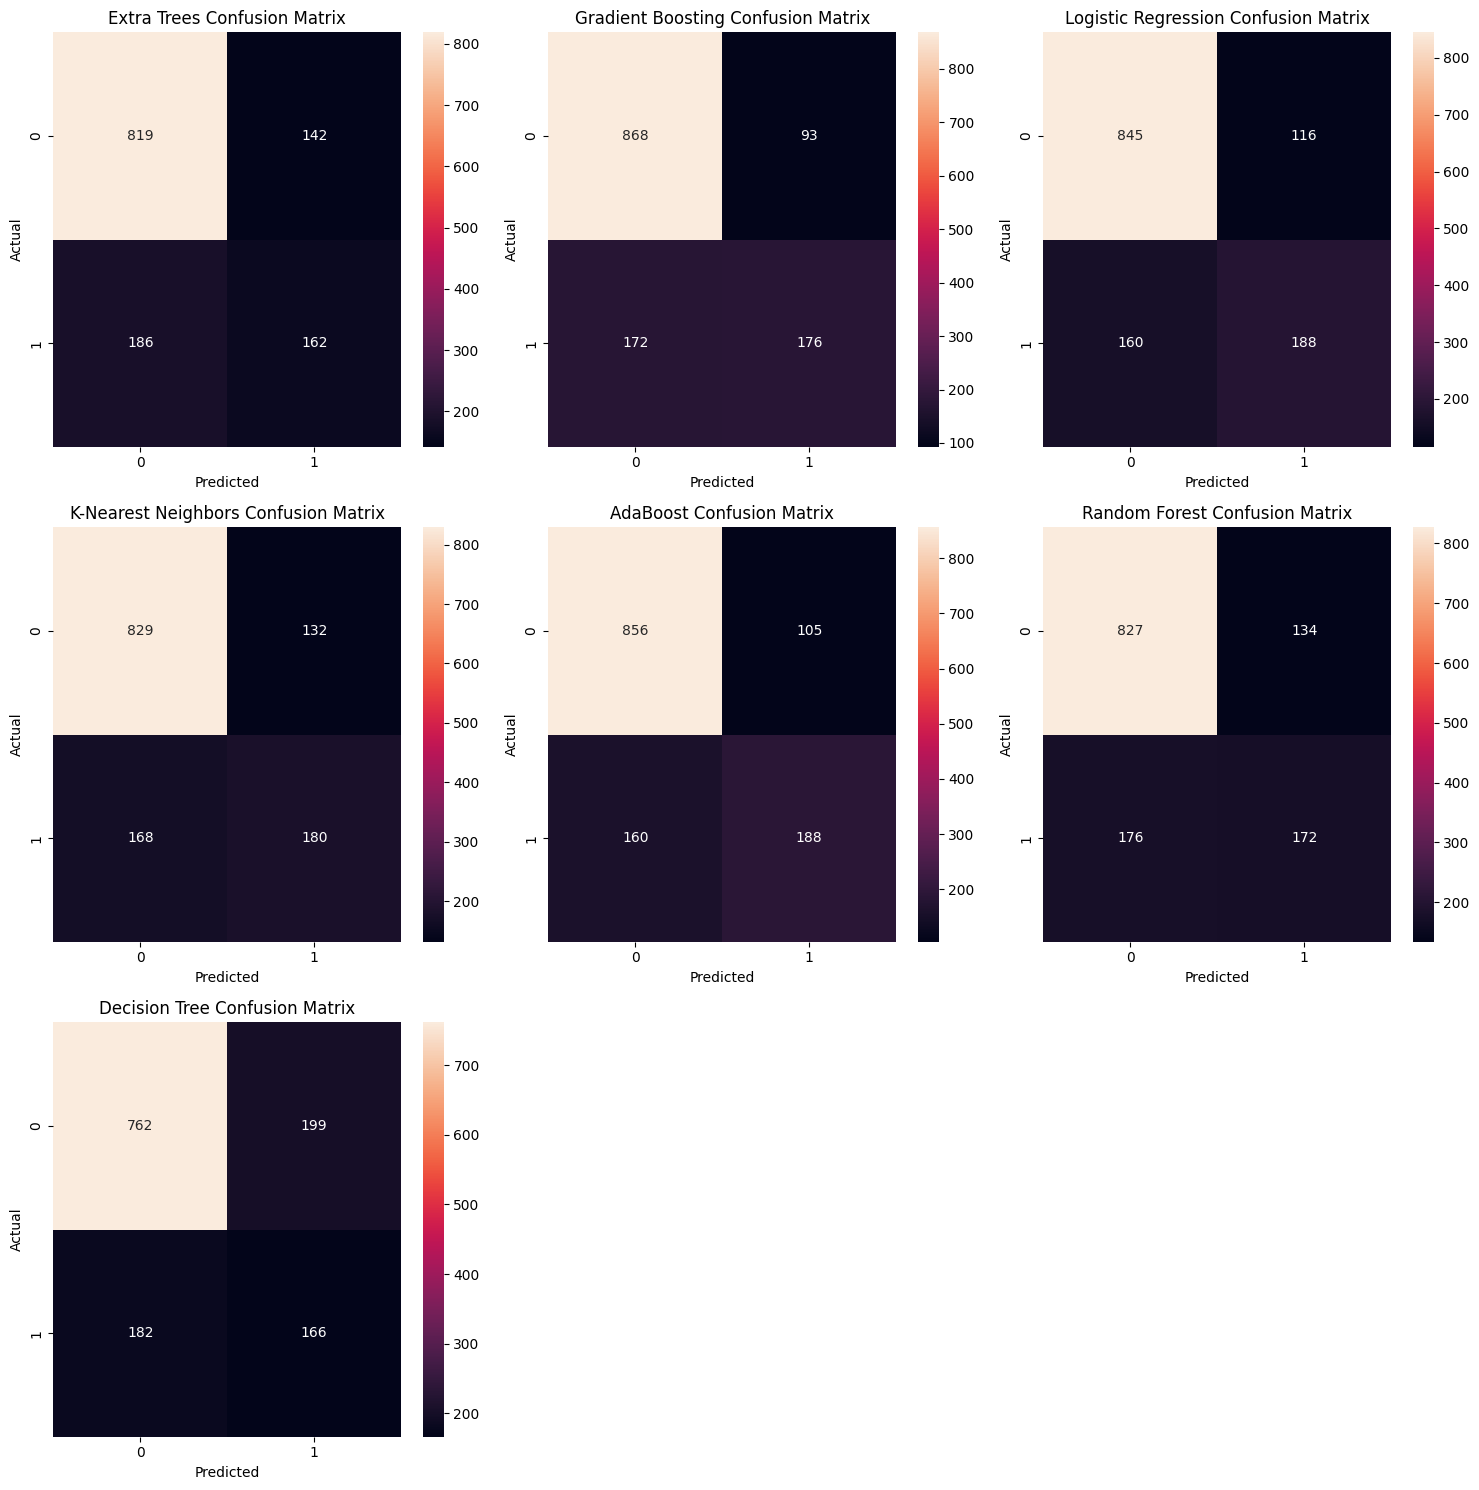

In [76]:
# Visualise confusion matrices
n_models = len(models)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, (name, result) in enumerate(results.items()):
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Remove the empty subplots
axes[-1].remove()
axes[-2].remove()

plt.tight_layout()
plt.show()


###Compare Accuracy

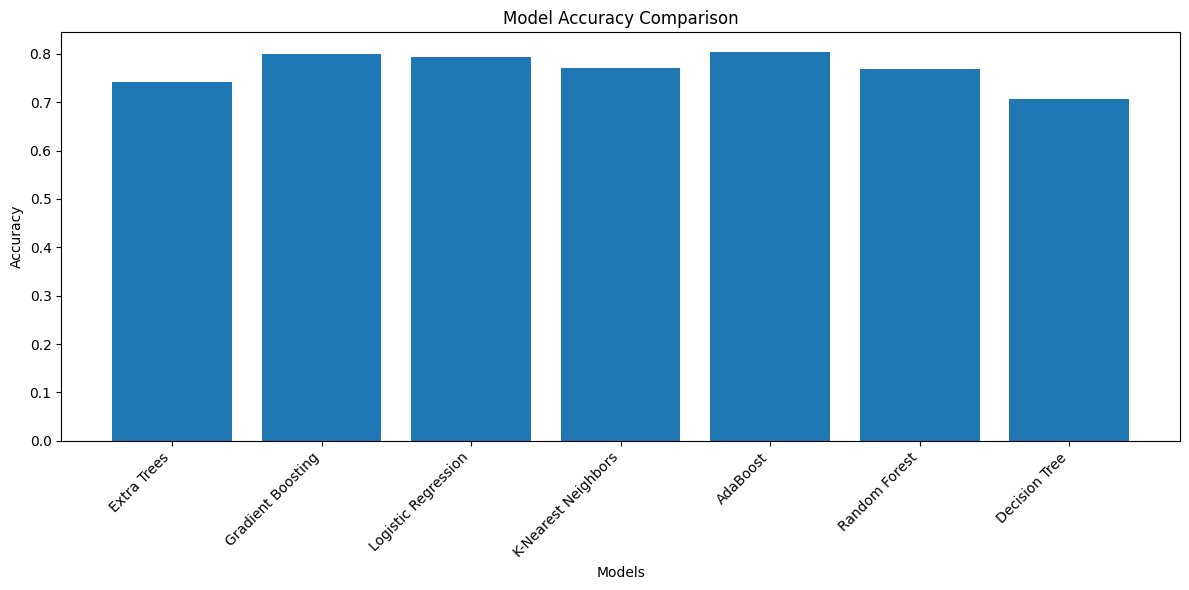

In [115]:
# Visualise accuracy comparison
accuracies = [result['accuracy'] for result in results.values()]
plt.figure(figsize=(12, 6))
plt.bar(results.keys(), accuracies)
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Review the coefficients for Logistic Regression Model

In [78]:
# Evaluate all models
for name, model in models.items():
    evaluate_model(model, name)


In [79]:
# Extract the Logistic Regression model
logistic_model = models['Logistic Regression'].named_steps['logisticregression']

In [80]:
# Get the coefficients
coefficients = logistic_model.coef_[0]
intercept = logistic_model.intercept_[0]

print("Logistic Regression Coefficients:")
for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef}")
print(f"Intercept: {intercept}")

# Apply to test dataset
X_sample_scaled = models['Logistic Regression'].named_steps['standardscaler'].transform(X_test)
y_pred_proba = logistic_model.predict_proba(X_sample_scaled)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

from sklearn.metrics import accuracy_score, classification_report

print("\nSample Dataset Predictions:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Logistic Regression Coefficients:
SeniorCitizen: 0.10740974584957505
tenure: -0.8943663837430601
MonthlyCharges: 0.5548364188531847
PhoneService_Yes: -0.2924790520191579
MultipleLines: 0.14675718532617116
multi_occupancy: -0.0757784250321936
additional_services: -0.1434868680862066
auto_payment: -0.169152574364382
internet_high_speed: 0.41838145708548713
internet_service: 0.16474737142467016
contract_monthly: 0.49987102877290157
Intercept: -1.567428048102084

Sample Dataset Predictions:
Accuracy: 0.7892

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       961
           1       0.62      0.54      0.58       348

    accuracy                           0.79      1309
   macro avg       0.73      0.71      0.72      1309
weighted avg       0.78      0.79      0.78      1309

Logistic Regression Coefficients:
SeniorCitizen: 0.10740974584957505
tenure: -0.8943663837430601
MonthlyCharges: 0.5548364188531847
PhoneSer

##Evaluate the model built to predict Churn

The logistic regression model achieves an accuracy of 78.92% on the sample dataset. It shows a good balance between precision and recall, especially for non-churning customers (class 0). Benefits of selecting the logistic regression (LR) model:

*   Relatively high accuracy (78.92%) on the sample dataset.
*   LR coefficients provide interpretability, showing the impact of each feature on churn probability.
*   Good balance between precision and recall, particularly for non-churning customers.
*   Provides probability scores, allowing for flexible decision thresholds.

**Model summary:**

*   The model correctly predicts 78.92% of all cases in the sample dataset.
*   62% of customers predicted to churn actually do churn (precision for class 1).
*   The model identifies 54% of all actual churners (recall for class 1).
*   F1-score for churn: 0.58, showing a reasonable balance between precision and recall for churners.



**Key insights from coefficients:**

*   Tenure has the strongest negative impact on churn (-0.8944), indicating longer-tenured customers are less likely to churn.
*   Monthly charges have a significant positive impact on churn (0.5548), suggesting higher bills increase churn risk.
*   Monthly contracts strongly increase churn probability (0.4999), compared to longer-term contracts.
*   High-speed internet service also increases churn risk (0.4184).
*   Phone service slightly decreases churn probability (-0.2925).
*   Auto-payment and additional services slightly reduce churn risk.

The model performs better at identifying non-churners (86% F1-score) than churners (58% F1-score). This suggests room for improvement in identifying potential churners, possibly through feature engineering or trying other algorithms.

##Key insights and Recommendations

Based on the analysis and model built, the key insights gained for predicting customer churn are:

*   Customer tenure is an important factor. Customers who have been with the company longer are less likely to churn.

*   Charges are correlated with churn. Higher monthly bills between £70-£100 are associated with more churn.

*   Contract type is a strong predictor. Month-to-month contracts have much higher churn rates compared to annual contracts

*   Understanding why the proportional of customers leaving have additional services could help us understand if there's an issue with any of these offers.

*   Understanding our demographic and digital maturity is important.

*   We recommend further analysis in: customer service interactions, reasons for leaving, and social media analysis.




# Reference List
Cartaya, C. (2021) 'Comparison of the logistic regression, decision tree, and random forest models to predict red wine quality in R,' Medium, 15 December. Available at: https://towardsdatascience.com/comparison-of-the-logistic-regression-decision-tree-and-random-forest-models-to-predict-red-wine-313d012d6953.(Accessed on 10/09/2024)